## Demand Forecasting

In [12]:
#%pip install matplotlib pandas
#%pip install pyarrow fastparquet
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow
import fastparquet
# -------------------------------
# 1. Load the dataset from parquet
# -------------------------------
# Make sure this path matches your local file location

#ADD THE SUPPLY AND DEMAND, SO CAN EDIT THE ALPHA MYSELF
dataset = pd.read_parquet('/Users/ryanaskin/Documents/datasci-challenge/renewables-dataset.parquet')

Try $D_{t+24} \sim N(\alpha_1 \times D_t + \alpha_2 \times d_{t-24(7)},\sigma^2)$ where $d_{t-i}=D_t - D_{t-i}$

In [13]:
a_s = 0.01 * 42.5 / 6  # solar matches (a_s x 100)% of the average yearly demand across EU
a_w = 0.05 * 42.5 / 6 # wind matches (a_w x 100)% of the average yearly demand across EU

# Compute scaled supply and residual load
dataset_residual = dataset.assign(
    solar_scaled_MWh=lambda df: a_s * df["solar_MWh"],
    wind_scaled_MWh=lambda df: a_w * df["wind_MWh"],
    supply_scaled_MWh=lambda df: df["solar_scaled_MWh"] + df["wind_scaled_MWh"],
    residual_MWh=lambda df: df["demand_MWh"] - df["supply_scaled_MWh"],
)[
    [
        "Time",
        "country",
        "solar_scaled_MWh",
        "wind_scaled_MWh",
        "demand_MWh",
        "supply_scaled_MWh",
        "residual_MWh",
    ]
]

dataset_residual.head()

,Time,country,solar_scaled_MWh,wind_scaled_MWh,demand_MWh,supply_scaled_MWh,residual_MWh
0,2012-01-01 00:00:00+00:00,POR,0.0,6.481831,75.6549,6.481831,69.173069
1,2012-01-01 00:00:00+00:00,POR,0.0,4.389124,557.8868,4.389124,553.497676
2,2012-01-01 00:00:00+00:00,POR,0.0,4.855684,15.5237,4.855684,10.668016
3,2012-01-01 00:00:00+00:00,POR,0.0,5.542065,8.6425,5.542065,3.100435
4,2012-01-01 00:00:00+00:00,POR,0.0,1.454697,85.3649,1.454697,83.910203


In [14]:
#dataset.head()
#plt.hist(dataset_residual["residual_MWh"],bins=30)
#print(min(dataset_residual["Time"]))
#print(max(dataset_residual["Time"]))

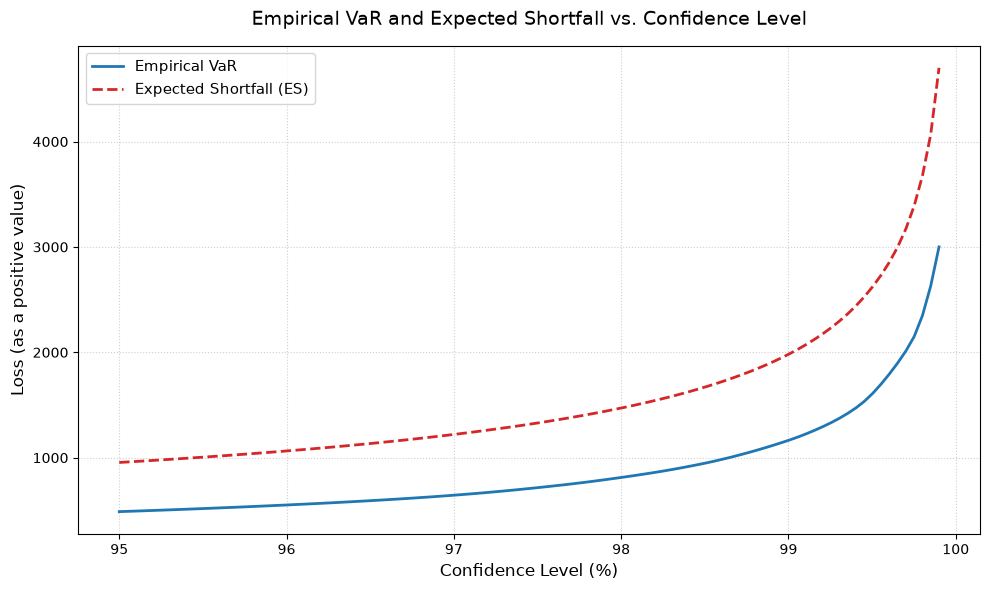

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

a_s = 0.01 * 42.5 / 6  # solar matches (a_s x 100)% of the average yearly demand across EU
a_w = 0.05 * 42.5 / 6 # wind matches (a_w x 100)% of the average yearly demand across EU


# Compute scaled supply and residual load
dataset_residual = dataset.assign(
    solar_scaled_MWh=lambda df: a_s * df["solar_MWh"],
    wind_scaled_MWh=lambda df: a_w * df["wind_MWh"],
    supply_scaled_MWh=lambda df: df["solar_scaled_MWh"] + df["wind_scaled_MWh"],
    residual_MWh=lambda df: df["demand_MWh"] - df["supply_scaled_MWh"],
)[
    [
        "Time",
        "country",
        "solar_scaled_MWh",
        "wind_scaled_MWh",
        "demand_MWh",
        "supply_scaled_MWh",
        "residual_MWh",
    ]
]

dataset_residual.head()

confidence_levels = np.linspace(0.95, 0.999, 100)

var_results = []
es_results = []

# --- 3. Compute Metrics Across Levels ---
# Cleaning the data to ensure no NaN values break the quantile function
transformed_residual =  dataset_residual['residual_MWh'].dropna()
transformed_residual = -transformed_residual

for cl in confidence_levels:
    tail_prob = 1 - cl
    
    # 1. Empirical Quantile (Value at Risk)
    var_cutoff = transformed_residual.quantile(tail_prob)
    empirical_var = -var_cutoff # Expressed as a positive loss
    
    # 2. Expected Shortfall
    tail_returns = transformed_residual[transformed_residual <= var_cutoff]
    expected_shortfall = -tail_returns.mean()  # Expressed as a positive loss
    
    var_results.append(empirical_var)
    es_results.append(expected_shortfall)

# --- 4. Plotting the Changes ---
# Configure plot dimensions globally using rcParams to avoid using .figure()
plt.rcParams['figure.figsize'] = (10, 6)

# Multiply confidence levels by 100 to show percentages on the x-axis
x_axis = confidence_levels * 100

plt.plot(x_axis, var_results, label='Empirical VaR', color='#1f77b4', linewidth=2)
plt.plot(x_axis, es_results, label='Expected Shortfall (ES)', color='#d62728', linewidth=2, linestyle='--')

# Layout and Labels
plt.title('Empirical VaR and Expected Shortfall vs. Confidence Level', fontsize=14, pad=15)
plt.xlabel('Confidence Level (%)', fontsize=12)
plt.ylabel('Loss (as a positive value)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

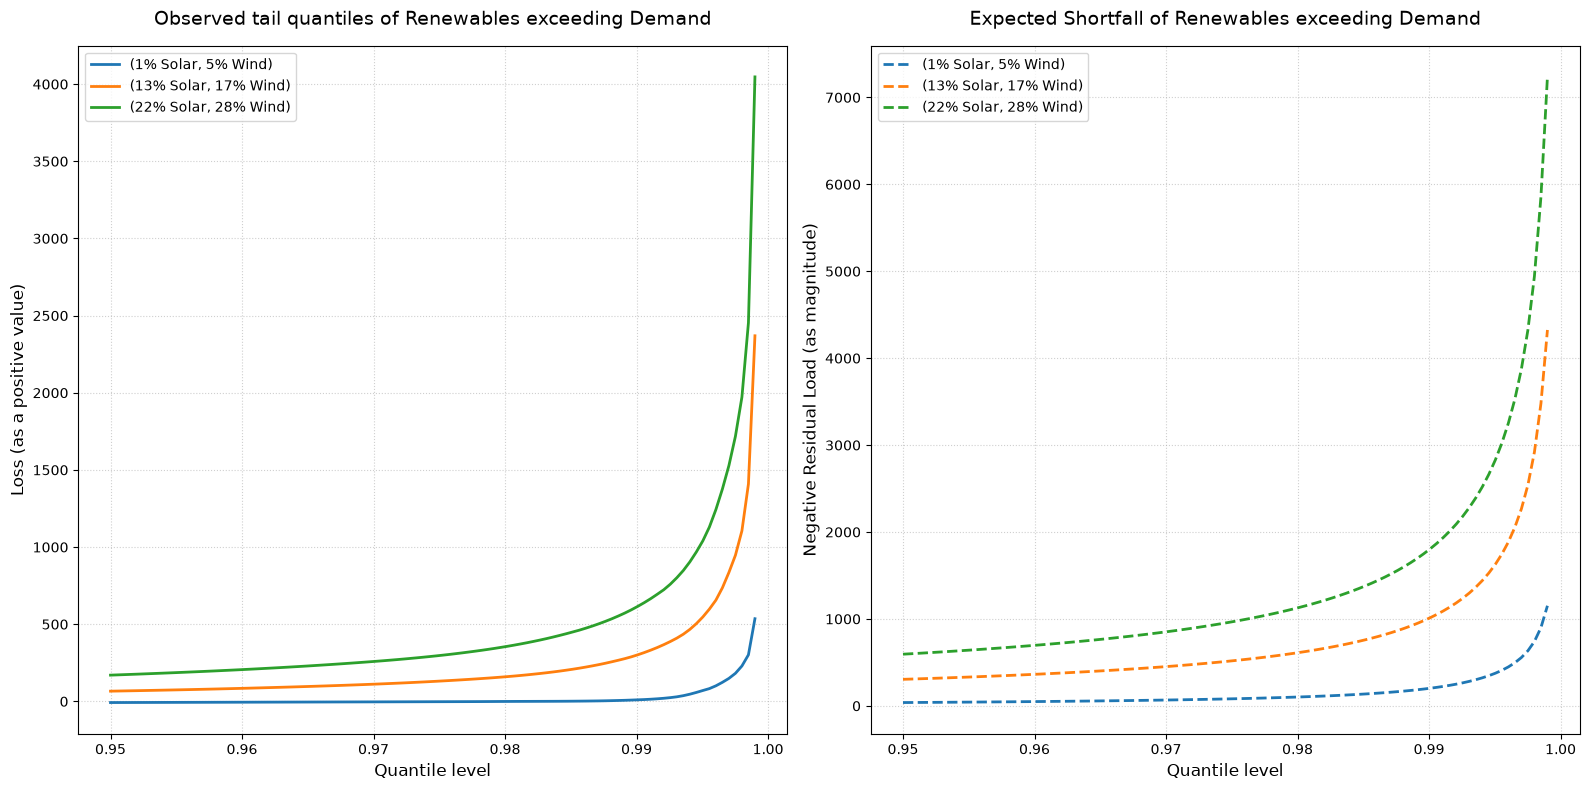

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Four configurations for (a_s, a_w) 
# Adjust the percentages (e.g., 0.01, 0.05) as needed for your specific scenarios
configs = {
    "(1% Solar, 5% Wind)":  {"a_s": 0.01, "a_w": 0.05},
    "(13% Solar, 17% Wind)":  {"a_s": 0.13, "a_w": 0.17},
    "(22% Solar, 28% Wind)": {"a_s": 0.22, "a_w": 0.28},
    #"Config 4 (5% Solar, 10% Wind)": {"a_s": 5 / 6 * base_factor2, "a_w": 1 / 6 * base_factor2},
}

confidence_levels = np.linspace(0.95, 0.999, 100)
x_axis = confidence_levels #* 100

# --- 2. Setup the Plots ---
# Create a figure with two side-by-side subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --- 3. Compute and Plot Across Configurations ---
for config_name, params in configs.items():
    a_s = params["a_s"]
    a_w = params["a_w"]
    
    # Calculate the scaled supply and residual load for this specific configuration
    # Note: Generating a series directly here is faster than recreating the entire DataFrame
    supply_scaled_MWh = (a_s * dataset["solar_MWh"]) + (a_w * dataset["wind_MWh"])
    residual_MWh = dataset["demand_MWh"] - supply_scaled_MWh
    
    # Clean the data to ensure no NaN values break the quantile function
    #transformed_residual =  dataset['residual_MWh'].dropna()
    transformed_residual = residual_MWh.dropna()

    var_results = []
    es_results = []
    
    # Calculate metrics across confidence levels
    for cl in confidence_levels:
        tail_prob = 1 - cl
        
        # 1. Empirical Quantile (Value at Risk)
        var_cutoff = transformed_residual.quantile(tail_prob)
        empirical_var = - var_cutoff  # Expressed as a positive loss
        
        # 2. Expected Shortfall
        tail_returns = transformed_residual[transformed_residual <= var_cutoff]
        expected_shortfall = - tail_returns.mean()  # Expressed as a positive loss
        
        var_results.append(empirical_var)
        es_results.append(expected_shortfall)
        
    # Plot the results for this configuration onto their respective axes
    ax1.plot(x_axis, var_results, label=config_name, linewidth=2)
    ax2.plot(x_axis, es_results, label=config_name, linewidth=2, linestyle='--')

# --- 4. Format Layout and Labels ---

# Formatting the VaR Plot (Left)
ax1.set_title('Observed tail quantiles of Renewables exceeding Demand', fontsize=14, pad=15)
ax1.set_xlabel('Quantile level', fontsize=12)
ax1.set_ylabel('Loss (as a positive value)', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=10)

# Formatting the Expected Shortfall Plot (Right)
ax2.set_title('Expected Shortfall of Renewables exceeding Demand', fontsize=14, pad=15)
ax2.set_xlabel('Quantile level', fontsize=12)
ax2.set_ylabel('Negative Residual Load (as magnitude)', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('var_es.pdf', bbox_inches="tight", transparent=False)
plt.show()

In [ ]:
#plot the extreme values, then highlight the months and countries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_multi_config_extreme_values(dataset, date_col, quantile_thresh=0.99):
    """
    Computes residual load for multiple parameter configurations, 
    filters for extreme values, and plots a side-by-side grouped 
    monthly histogram comparing all configurations.
    """
    # 1. Define the configurations (from Code 1)
    configs = {
        "(1% Solar, 5% Wind)":  {"a_s": 0.01, "a_w": 0.05},
        "(13% Solar, 17% Wind)":  {"a_s": 0.13, "a_w": 0.17},
        "(22% Solar, 28% Wind)": {"a_s": 0.22, "a_w": 0.28},
    }
    
    # Define a distinct color for each of the 3 configurations
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green
    
    # Storage lists to hold the data and labels for the final histogram
    all_config_dates = []
    labels = []
    
    # 2. Loop Through Configurations to Process Data
    for config_name, params in configs.items():
        a_s = params["a_s"]
        a_w = params["a_w"]
        
        # Create a temporary dataframe slice to protect original data
        df_temp = dataset[[date_col, "demand_MWh", "solar_MWh", "wind_MWh"]].copy()
        
        # Calculate scaled supply and residual load for this specific setup
        supply_scaled_MWh = (a_s * df_temp["solar_MWh"]) + (a_w * df_temp["wind_MWh"])
        residual_MWh = df_temp["demand_MWh"] - supply_scaled_MWh
        
        # Express as positive loss and drop NaNs so quantiles don't break
        df_temp['residual'] = residual_MWh
        df_temp = df_temp.dropna(subset=['residual'])

        threshold_value = df_temp['residual'].quantile(1 - quantile_thresh)   # 0.01
        extreme_df = df_temp[df_temp['residual'] < threshold_value].copy()
        print("Extreme values length of data")
        print(np.mean(extreme_df))
        #extreme_df = extreme_df.sample(n=min(10000, len(extreme_df)), random_state=42)

        # Standardize dates and map them to the dummy leap year (2024)
        extreme_df[date_col] = pd.to_datetime(extreme_df[date_col])
        extreme_df['dummy_date'] = extreme_df[date_col].apply(lambda x: x.replace(year=2024))
        
        # Collect the dates series and the label for plotting
        all_config_dates.append(extreme_df['dummy_date'])
        labels.append(config_name)
        
    # 3. Setup and Plot the Grouped Histogram
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Generate explicit monthly bin edges for 2024 to ensure precise alignment
    bin_edges = pd.date_range(start='2024-01-01', end='2025-01-01', freq='MS')
    
    # Passing the list of series here triggers the automatic side-by-side grouped bars
    ax.hist(
        all_config_dates, 
        bins=bin_edges, 
        color=colors[:len(labels)], 
        label=labels,
        edgecolor='black', 
        alpha=0.85,
        rwidth=0.85  # Adds a nice visual gap between monthly groups
    )
    
    # --- 4. Format Layout and Labels ---
    # Format X-axis to display abbreviated month names
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    
    ax.set_xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
    ax.set_xlabel('Months Through the Year', fontsize=12, labelpad=10)
    ax.set_ylabel('Count of Extreme Events', fontsize=12, labelpad=10)
    ax.set_title(f'Negative tail risk (99%)', fontsize=14, pad=15)
    
    # Only use horizontal grid lines to keep the look uncluttered
    ax.grid(True, linestyle='--', alpha=0.5, axis='y')
    ax.legend(fontsize=11, loc='upper right')
    
    plt.savefig('monthly_peaks.pdf', bbox_inches="tight", transparent=False)
    plt.tight_layout()
    return ax

plot_multi_config_extreme_values(dataset,'Time')

Extreme values length of data


TypeError: unsupported operand type(s) for +: 'Timestamp' and 'Timestamp'

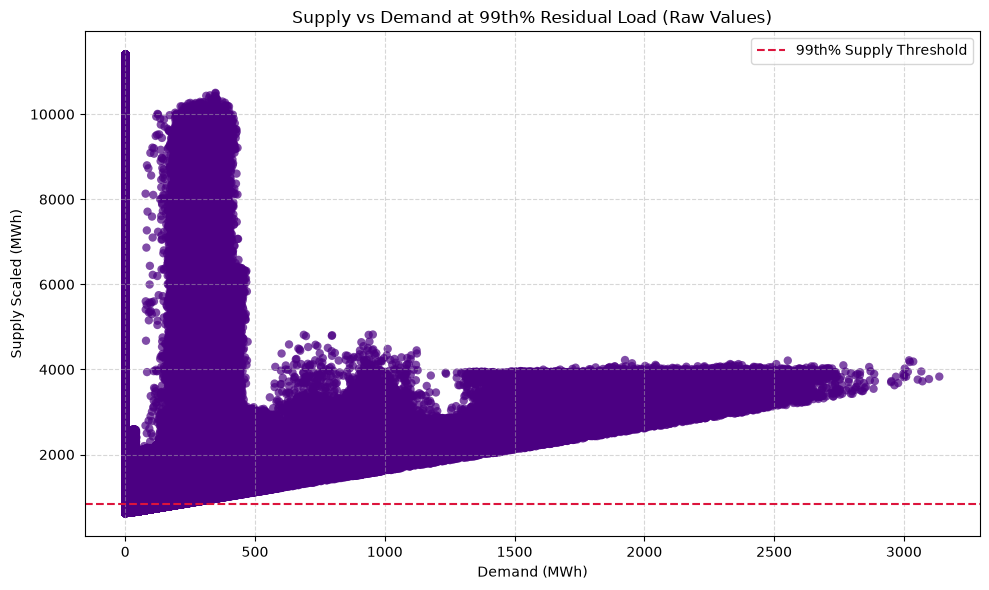

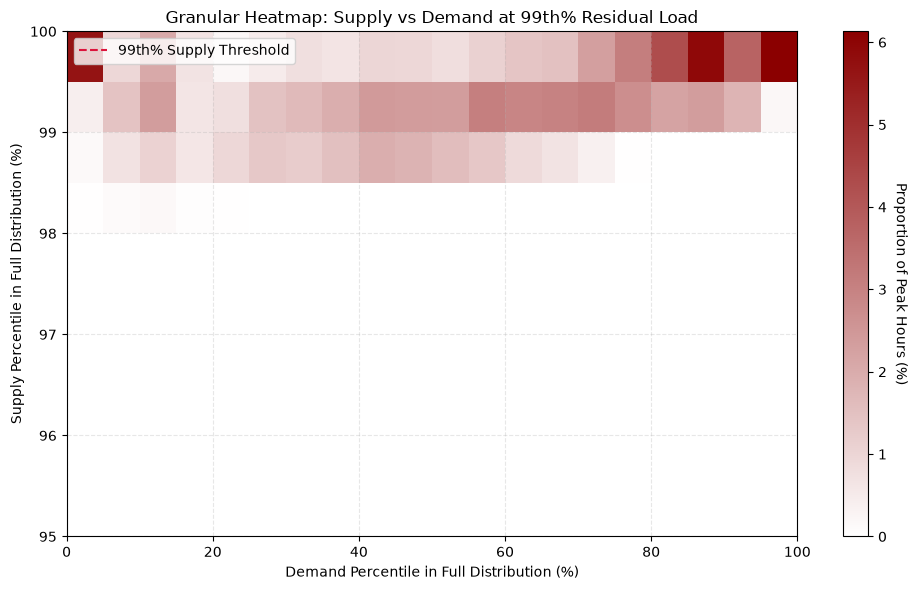

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load or simulate the dataset
# Replace this block with your actual data loading step, e.g.:
# df = pd.read_csv('your_dataset.csv')

df = dataset

a_s = 0.22
a_w = 0.28

# 1. Calculate the core variables and assign them directly to the DataFrame
df["supply_scaled_MWh"] = (a_s * df["solar_MWh"]) + (a_w * df["wind_MWh"])
df["residual_MWh"] = df["demand_MWh"] - df["supply_scaled_MWh"]
df["residual_MWh"] = - df["residual_MWh"]
# Clean the data to ensure no NaN values break the quantile/ranking functions
df = df.dropna(subset=["demand_MWh", "supply_scaled_MWh", "residual_MWh"])

# 2. Compute the percentile rank of each row relative to the FULL distribution
df["demand_percentile_full"] = df["demand_MWh"].rank(pct=True) * 100
df["supply_percentile_full"] = df["supply_scaled_MWh"].rank(pct=True) * 100

# 3. Filter the DATAFRAME for data points at or above the 99th percentile of residual_load
residual_99th_threshold = df["residual_MWh"].quantile(0.99)
df_99th = df[df["residual_MWh"] >= residual_99th_threshold]

import matplotlib.pyplot as plt
import numpy as np

# --- 1. Scatterplot Variant A: Raw Values (Supply on Y) ---
# Calculate the 99th percentile of demand for the vertical threshold line
supply_99th = df["supply_scaled_MWh"].quantile(0.99)

plt.scatter(df_99th['demand_MWh'], df_99th['supply_scaled_MWh'], alpha=0.7, color='indigo', edgecolor='none')

plt.axhline(y=supply_99th, color='crimson', linestyle='--', linewidth=1.5, label='99th% Supply Threshold')

plt.title('Supply vs Demand at 99th% Residual Load (Raw Values)')
plt.xlabel('Demand (MWh)')
plt.ylabel('Supply Scaled (MWh)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Calculate weights based on the supply variable length (identical to demand length)
weights = np.ones_like(df_99th['supply_percentile_full']) * 100.0 / len(df_99th)

from matplotlib.colors import LinearSegmentedColormap
white_to_color = LinearSegmentedColormap.from_list('white_to_color', ['#ffffff', 'darkred'])
# Swapped columns in hist2d: X is now demand (95-100), Y is now supply (0-100)
# Swapped bins and ranges to match the new axis assignments
plt.hist2d(
    df_99th['demand_percentile_full'], 
    df_99th['supply_percentile_full'], 
    bins=[20, 10],  # 20 bins for X (0-100), 20 bins for Y (95-100)
    range=[[0, 100], [95, 100]], 
    weights=weights,
    cmap=white_to_color  # <--- Using your custom white-start colormap here
)

# Add a colorbar scaled to %
cbar = plt.colorbar()
cbar.set_label('Proportion of Peak Hours (%)', rotation=270, labelpad=15)

plt.axhline(y=supply_99th, color='crimson', linestyle='--', linewidth=1.5, label='99th% Supply Threshold')

plt.title('Heatmap: Supply vs Demand at 99th% Residual Load')
plt.xlabel('Demand Percentile in Full Distribution (%)')
plt.ylabel('Supply Percentile in Full Distribution (%)')

# Explicitly set axis limits to match the flipped orientation
plt.xlim(0, 100)
plt.ylim(95, 100)

plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Processing Config 1: a_s=0.01, a_w=0.05


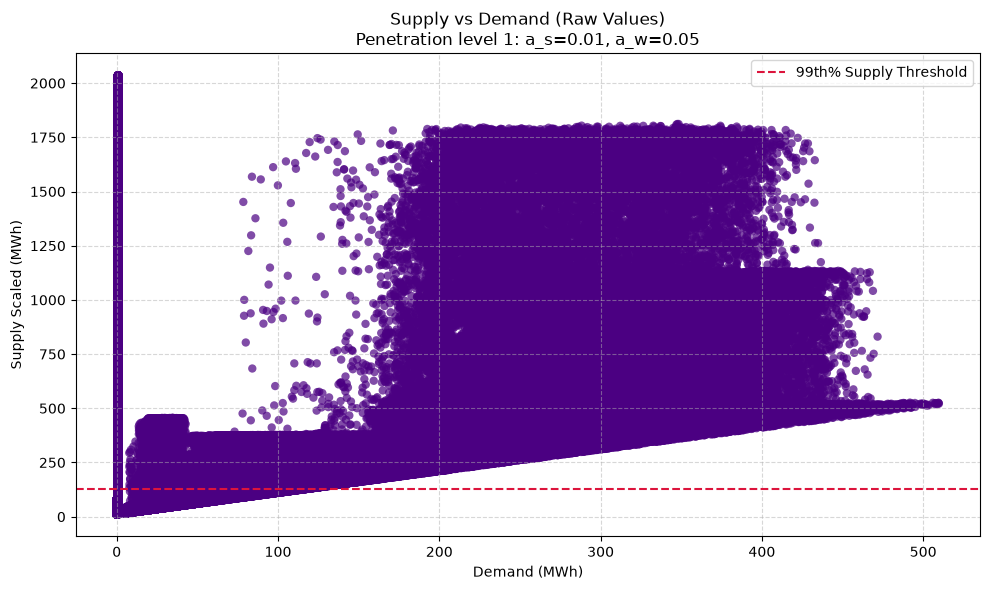

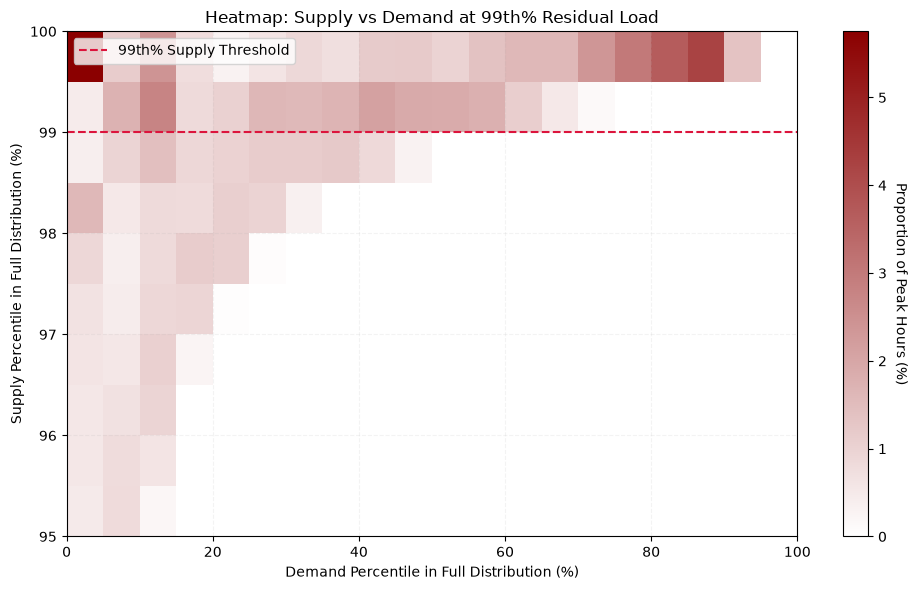

--------------------------------------------------
Processing Config 2: a_s=0.13, a_w=0.17


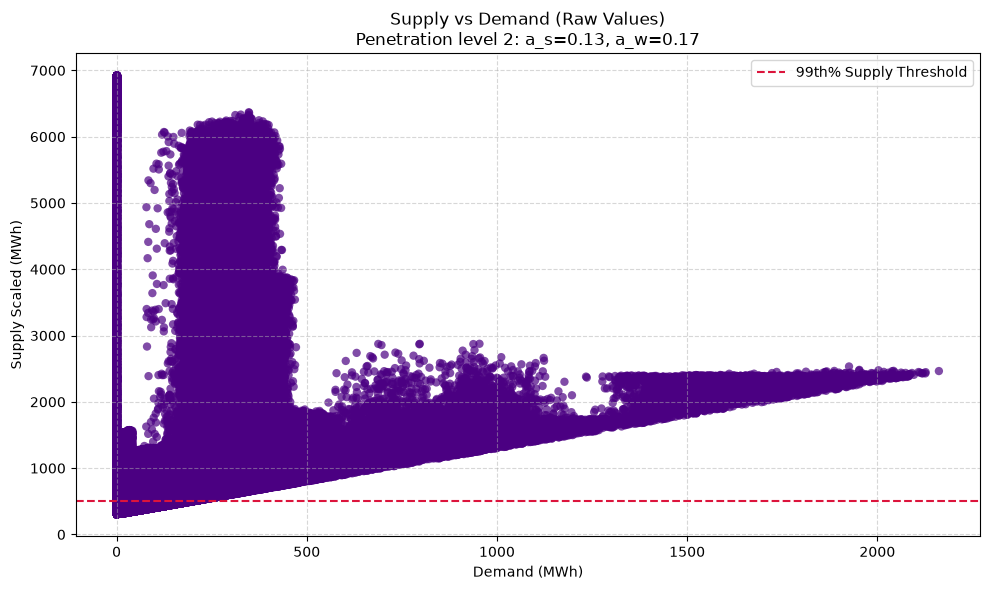

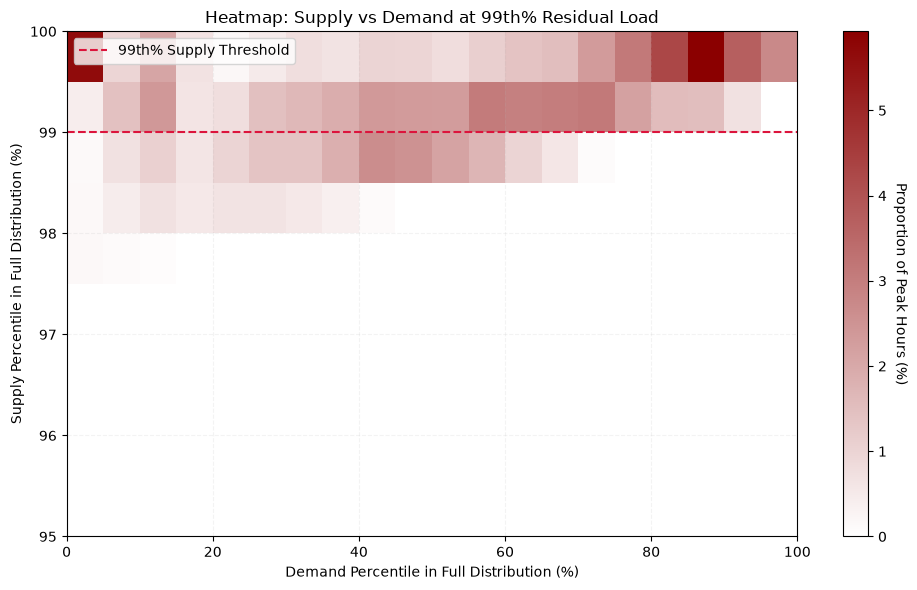

--------------------------------------------------
Processing Config 3: a_s=0.22, a_w=0.28


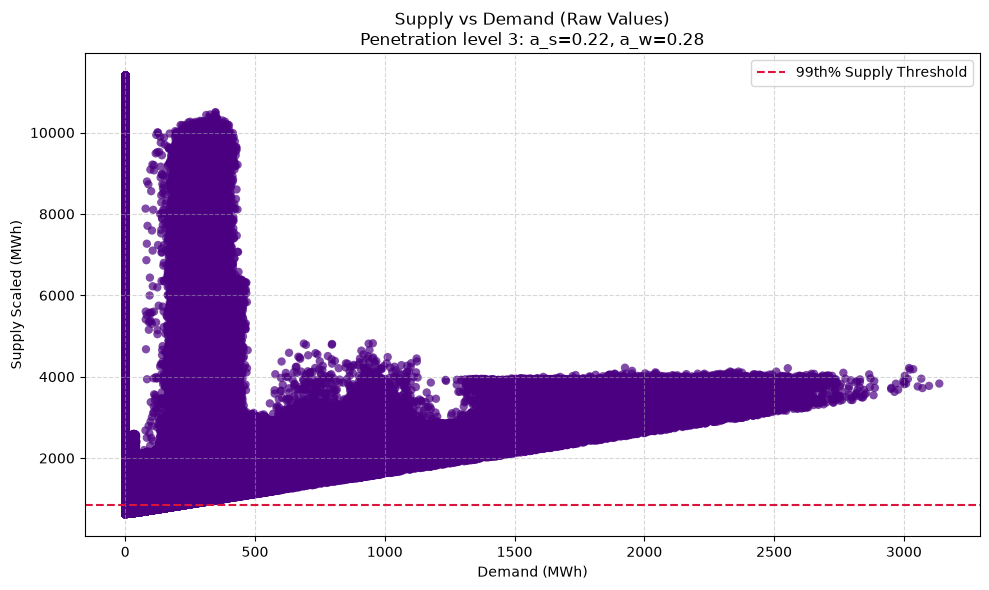

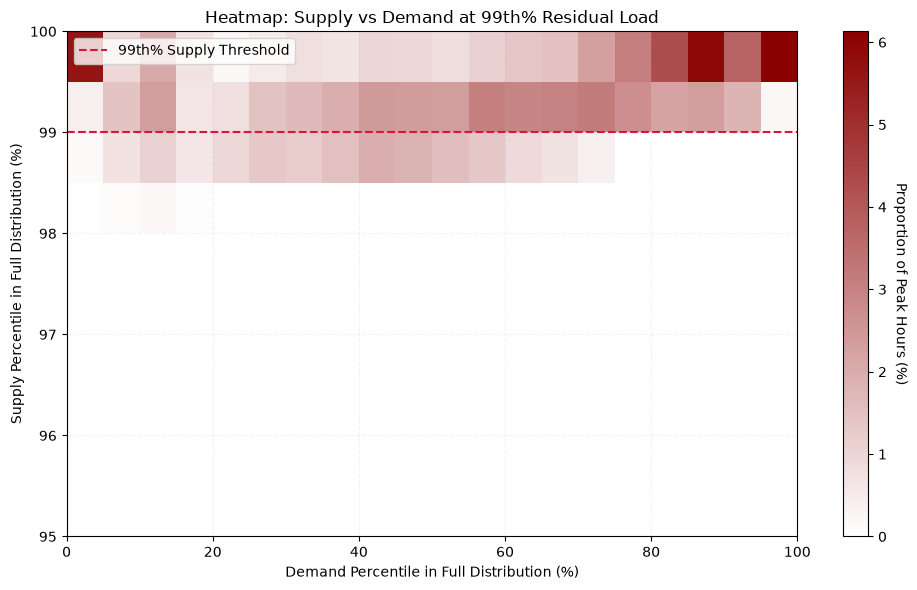

--------------------------------------------------


In [28]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Define your 3 configurations for a_s (solar) and a_w (wind)
configs = [
    {"a_s": 0.01, "a_w": 0.05},
    {"a_s": 0.13, "a_w": 0.17},
    {"a_s": 0.22, "a_w": 0.28}
]

# Create the custom colormap once (White to Dark Red)
white_to_color = LinearSegmentedColormap.from_list('white_to_color', ['#ffffff', 'darkred'])

# Store a clean copy of the dataframe to reset it at the start of each loop
df_base = dataset.copy()

for i, cfg in enumerate(configs, start=1):
    a_s = cfg["a_s"]
    a_w = cfg["a_w"]
    print(f"Processing Config {i}: a_s={a_s}, a_w={a_w}")
    
    # Always work off a fresh copy of the base data so column transformations don't stack up
    df = df_base.copy()

    # 1. Calculate the core variables and assign them directly to the DataFrame
    df["supply_scaled_MWh"] = (a_s * df["solar_MWh"]) + (a_w * df["wind_MWh"])
    df["residual_MWh"] = df["demand_MWh"] - df["supply_scaled_MWh"]
    df["residual_MWh"] = - df["residual_MWh"]
    
    # Clean the data to ensure no NaN values break the quantile/ranking functions
    df = df.dropna(subset=["demand_MWh", "supply_scaled_MWh", "residual_MWh"])

    # 2. Compute the percentile rank of each row relative to the FULL distribution
    df["demand_percentile_full"] = df["demand_MWh"].rank(pct=True) * 100
    df["supply_percentile_full"] = df["supply_scaled_MWh"].rank(pct=True) * 100

    # 3. Filter the DATAFRAME for data points at or above the 99th percentile of residual_load
    residual_99th_threshold = df["residual_MWh"].quantile(0.99)
    df_99th = df[df["residual_MWh"] >= residual_99th_threshold]

    # --- GRAPH 1: Scatterplot Variant A (Raw Values) ---
    plt.figure() # Opens a clean figure space
    supply_99th = df["supply_scaled_MWh"].quantile(0.99)

    plt.scatter(df_99th['demand_MWh'], df_99th['supply_scaled_MWh'], alpha=0.7, color='indigo', edgecolor='none')
    plt.axhline(y=supply_99th, color='crimson', linestyle='--', linewidth=1.5, label='99th% Supply Threshold')

    plt.title(f'Supply vs Demand (Raw Values)\nPenetration level {i}: a_s={a_s}, a_w={a_w}')
    plt.xlabel('Demand (MWh)')
    plt.ylabel('Supply Scaled (MWh)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    plt.close() # Safely closes the figure space

    # --- GRAPH 2: Granular Heatmap (Percentiles) ---
    plt.figure()
    
    # Calculate weights based on the current configuration's filtered length
    weights = np.ones_like(df_99th['supply_percentile_full']) * 100.0 / len(df_99th)

    plt.hist2d(
        df_99th['demand_percentile_full'], 
        df_99th['supply_percentile_full'], 
        bins=[20, 10],  # 20 bins for X (0-100), 10 bins for Y (95-100)
        range=[[0, 100], [95, 100]], 
        weights=weights,
        cmap=white_to_color
    )

    # Add a colorbar scaled to %
    cbar = plt.colorbar()
    cbar.set_label('Proportion of Peak Hours (%)', rotation=270, labelpad=15)

    # Note: On a percentile axis (95-100), the 99th percentile line is literally at y=99
    plt.axhline(y=99, color='crimson', linestyle='--', linewidth=1.5, label='99th% Supply Threshold')

    plt.title('Heatmap: Supply vs Demand at 99th% Residual Load')
    plt.xlabel('Demand Percentile in Full Distribution (%)')
    plt.ylabel('Supply Percentile in Full Distribution (%)')

    # Explicitly set axis limits to match the flipped orientation
    plt.xlim(0, 100)
    plt.ylim(95, 100)

    plt.grid(True, linestyle='--', alpha=0.15)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()
    plt.close()
    
    print("-" * 50) # Visual separator in the console output
